### Imports and Data imports

In [ ]:
from google.colab import drive
import os, shutil, kagglehub

# 1. Mount Google Drive
drive.mount("/content/drive")

# 2. Find kaggle.json in your Drive
matches = []
for root, dirs, files in os.walk("/content/drive/MyDrive"):
    if "kaggle.json" in files:
        matches.append(os.path.join(root, "kaggle.json"))

if not matches:
    raise FileNotFoundError("Could not find kaggle.json in /content/drive/MyDrive")

src = matches[0]
print("Found kaggle.json at:", src)

# 3. Copy kaggle.json to the location KaggleHub expects
dst_dir = "/root/.kaggle"
dst = os.path.join(dst_dir, "kaggle.json")

os.makedirs(dst_dir, exist_ok=True)
shutil.copy(src, dst)
os.chmod(dst, 0o600)

print("Copied Kaggle credentials to:", dst)

# 4. Download the competition files
path = kagglehub.competition_download(
    "ethz-cil-monocular-depth-estimation-2026"
)

print("Path to competition files:", path)

Mounted at /content/drive
Found kaggle.json at: /content/drive/MyDrive/kaggle.json
Copied Kaggle credentials to: /root/.kaggle/kaggle.json


100%|██████████| 20.6G/20.6G [19:26<00:00, 19.0MB/s]

Extracting files...


Path to competition files: /root/.cache/kagglehub/competitions/ethz-cil-monocular-depth-estimation-2026


In [ ]:
ls -a /root/.cache/kagglehub/competitions/ethz-cil-monocular-depth-estimation-2026/monodepth_kaggle2026/train

./                      train_007534_rgb.png    train_015070_depth.npy
../                     train_007535_depth.npy  train_015070_rgb.png
train_000000_depth.npy  train_007535_rgb.png    train_015071_depth.npy
train_000000_rgb.png    train_007536_depth.npy  train_015071_rgb.png
train_000001_depth.npy  train_007536_rgb.png    train_015072_depth.npy
train_000001_rgb.png    train_007537_depth.npy  train_015072_rgb.png
train_000002_depth.npy  train_007537_rgb.png    train_015073_depth.npy
train_000002_rgb.png    train_007538_depth.npy  train_015073_rgb.png
train_000003_depth.npy  train_007538_rgb.png    train_015074_depth.npy
train_000003_rgb.png    train_007539_depth.npy  train_015074_rgb.png
train_000004_depth.npy  train_007539_rgb.png    train_015075_depth.npy
train_000004_rgb.png    train_007540_depth.npy  train_015075_rgb.png
train_000005_depth.npy  train_007540_rgb.png    train_015076_depth.npy
train_000005_rgb.png    train_007541_depth.npy  train_015076_rgb.png
train_000006_depth.n

In [ ]:
import os
import csv
import time
from pathlib import Path
import random
import numpy as np
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.amp import autocast, GradScaler

import matplotlib.pyplot as plt

In [ ]:
# ---- paths ----
DATA_ROOT = Path("/root/.cache/kagglehub/competitions/ethz-cil-monocular-depth-estimation-2026/monodepth_kaggle2026/train")

# ---- training config ----
IMG_SIZE = 320
BATCH_SIZE  = 12
NUM_EPOCHS = 100
LR = 1e-3
MAX_TRAIN_SAMPLES = 19600
MAX_VAL_SAMPLES   = 3000
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# ---- outputs ----
# SAVE_PATH may be either a directory or a checkpoint file path.
SAVE_PATH = os.getcwd()
SAVE_PATH = Path(SAVE_PATH)

if SAVE_PATH.suffix:
    CHECKPOINT_PATH = SAVE_PATH
    OUTPUT_DIR = SAVE_PATH.parent
else:
    OUTPUT_DIR = SAVE_PATH
    CHECKPOINT_PATH = OUTPUT_DIR / "model_checkpoint.pt"

TRAINING_LOG_CSV_PATH = OUTPUT_DIR / "training_log.csv"

start_epoch = 0

print("Output directory:", OUTPUT_DIR)
print("Checkpoint path:", CHECKPOINT_PATH)
print("Training log CSV:", TRAINING_LOG_CSV_PATH)
print("Using device:", DEVICE)


Output directory: /content
Checkpoint path: /content/model_checkpoint.pt
Training log CSV: /content/training_log.csv
Using device: cuda


In [ ]:
class SimpleDepthDataset(Dataset):
    def __init__(self, root: Path, img_size=128, max_samples=None):
        self.root = Path(root)
        self.img_size = img_size

        self.rgb_files = sorted(self.root.glob("*_rgb.png"))
        if max_samples is not None:
            self.rgb_files = self.rgb_files[:max_samples]

        assert len(self.rgb_files) > 0, f"No *_rgb.png files found in {self.root}"

    def __len__(self):
        return len(self.rgb_files)

    def __getitem__(self, idx):
        rgb_path = self.rgb_files[idx]
        depth_path = Path(str(rgb_path).replace("_rgb.png", "_depth.npy"))

        # load rgb
        rgb = np.array(Image.open(rgb_path).convert("RGB"), dtype=np.float32) / 255.0

        # load depth
        depth = np.load(depth_path).astype(np.float32)

        # resize rgb
        rgb_t = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0)   # [1,3,H,W]
        rgb_t = F.interpolate(rgb_t, size=(self.img_size, self.img_size), mode="bilinear", align_corners=False)
        rgb_t = rgb_t.squeeze(0)  # [3,H,W]

        # resize depth
        depth_t = torch.from_numpy(depth).unsqueeze(0).unsqueeze(0)   # [1,1,H,W]
        depth_t = F.interpolate(depth_t, size=(self.img_size, self.img_size), mode="nearest")
        depth_t = depth_t.squeeze(0)  # [1,H,W]

        # valid mask: depth > 0
        valid_mask = (depth_t > 0).float()

        # optional normalization of valid depth values
        # keeps the target range smaller and easier for the toy model
        depth_t = torch.clamp(depth_t, min=0.0, max=80.0)
        depth_t = depth_t / 80.0

        return {
            "image": rgb_t,
            "depth": depth_t,
            "mask": valid_mask,
            "name": rgb_path.name
        }

In [ ]:
full_dataset = SimpleDepthDataset(DATA_ROOT, img_size=IMG_SIZE, max_samples=MAX_TRAIN_SAMPLES + MAX_VAL_SAMPLES)

n_total = len(full_dataset)
n_val = min(MAX_VAL_SAMPLES, max(1, int(0.15 * n_total)))
n_train = n_total - n_val

train_dataset, val_dataset = random_split(
    full_dataset,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,pin_memory=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,pin_memory=True, num_workers=2)

print(f"Train samples: {len(train_dataset)}")
print(f"Val samples:   {len(val_dataset)}")

Train samples: 19600
Val samples:   3000


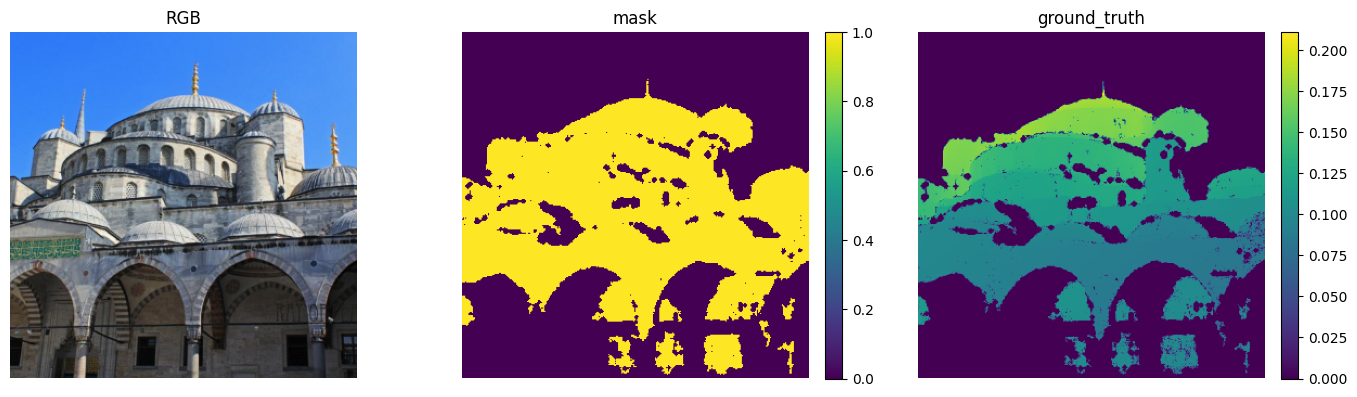

In [ ]:
batch = next(iter(train_loader))
images = batch["image"].to(DEVICE)
depths = batch["depth"].to(DEVICE)
masks = batch["mask"].to(DEVICE)
names = batch["name"]
plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(images[0].cpu().permute(1, 2, 0).numpy())
plt.title("RGB")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(masks[0].cpu().permute(1, 2, 0).numpy())
plt.title("mask")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 3, 3)
plt.imshow(depths[0].cpu().permute(1, 2, 0).numpy(), cmap="viridis")
plt.title("ground_truth")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

# plt.suptitle(names[i])
plt.tight_layout()

### Create Neural Network

In [ ]:
import torch.nn.functional as F
class CovarianceFeatures(nn.Module):
    def __init__(self, patch_size=3):
        super().__init__()
        self.patch_size = patch_size
        self.unfold = nn.Unfold(kernel_size=patch_size, padding=patch_size//2, stride=1)

    def forward(self, x):
        # x: [B,3,H,W]
        B, C, H, W = x.shape
        patches = self.unfold(x)
        patches = patches.view(B, C, self.patch_size*self.patch_size, H, W)
        mean = patches.mean(dim=2, keepdim=True)
        centered = patches - mean
        cov_rg = (centered[:,0] * centered[:,1]).mean(dim=2, keepdim=True)  # [B,1,H,W]
        cov_rb = (centered[:,0] * centered[:,2]).mean(dim=2, keepdim=True)
        cov_gb = (centered[:,1] * centered[:,2]).mean(dim=2, keepdim=True)
        var_r = (centered[:,0]**2).mean(dim=2, keepdim=True)
        var_g = (centered[:,1]**2).mean(dim=2, keepdim=True)
        var_b = (centered[:,2]**2).mean(dim=2, keepdim=True)
        cov_features = torch.cat([var_r, var_g, var_b, cov_rg, cov_rb, cov_gb], dim=1)
        return cov_features
class ConvBlock(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        groups = max(1, min(8, out_ch // 4))
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(groups, out_ch),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, bias=False),
            nn.GroupNorm(groups, out_ch),
            nn.SiLU(inplace=True),
        )

    def forward(self, x):
        return self.net(x)
class DoubleConv(nn.Module):
    """BN → GN swap: GroupNorm is stable across batch sizes and in eval mode."""
    def __init__(self, in_ch, out_ch):
        super().__init__()
        groups = max(1, min(16, out_ch // 4))
        self.net = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_ch),
            nn.SiLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1, bias=False),
            nn.GroupNorm(groups, out_ch),
            nn.SiLU(inplace=True),
        )
    def forward(self, x):
        return self.net(x)


class ASPPBottleneck(nn.Module):
    """Atrous Spatial Pyramid Pooling — captures multi-scale context cheaply."""
    def __init__(self, in_ch, out_ch, rates=(1, 6, 12, 18)):
        super().__init__()
        mid = in_ch // len(rates)
        self.branches = nn.ModuleList([
            nn.Sequential(
                nn.Conv2d(in_ch, mid, 3, padding=r, dilation=r, bias=False),
                nn.GroupNorm(max(1, mid // 4), mid),
                nn.SiLU(inplace=True),
            ) for r in rates
        ])
        self.pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_ch, mid, 1, bias=False),
            nn.SiLU(inplace=True),
        )
        fused = mid * (len(rates) + 1)
        self.project = nn.Sequential(
            nn.Conv2d(fused, out_ch, 1, bias=False),
            nn.GroupNorm(max(1, out_ch // 4), out_ch),
            nn.SiLU(inplace=True),
            nn.Dropout2d(0.1),
        )
    def forward(self, x):
        h, w = x.shape[2:]
        parts = [b(x) for b in self.branches]
        pooled = F.interpolate(self.pool(x), size=(h, w), mode='bilinear', align_corners=False)
        return self.project(torch.cat(parts + [pooled], dim=1))


class BetterUNet(nn.Module):
    """
    4-level UNet with GroupNorm + SiLU throughout and an ASPP bottleneck.
    Stable across batch sizes, works correctly in eval() mode.
    ~4M params at features=[32,64,128,256].
    """
    def __init__(self, in_channels=3, out_channels=1, features=(64, 128, 256, 512)):
        super().__init__()
        self.features = features
        f = features

        # Encoder
        self.enc1 = DoubleConv(in_channels, f[0])
        self.enc2 = DoubleConv(f[0], f[1])
        self.enc3 = DoubleConv(f[1], f[2])
        self.enc4 = DoubleConv(f[2], f[3])
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ASPPBottleneck(f[3], f[3] * 2)

        # Decoder (upsample → concat skip → conv)
        self.up4   = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                                   nn.Conv2d(f[3]*2, f[3], 1, bias=False))
        self.dec4  = DoubleConv(f[3]*2, f[3])

        self.up3   = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                                   nn.Conv2d(f[3], f[2], 1, bias=False))
        self.dec3  = DoubleConv(f[2]*2, f[2])

        self.up2   = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                                   nn.Conv2d(f[2], f[1], 1, bias=False))
        self.dec2  = DoubleConv(f[1]*2, f[1])

        self.up1   = nn.Sequential(nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
                                   nn.Conv2d(f[1], f[0], 1, bias=False))
        self.dec1  = DoubleConv(f[0]*2, f[0])

        self.out_conv = nn.Conv2d(f[0], out_channels, 1)

        self._init_weights()

    def _init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Conv2d):
                nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))

        b = self.bottleneck(self.pool(e4))

        def up_cat_conv(up, dec, feat, skip):
            d = up(feat)
            if d.shape[2:] != skip.shape[2:]:
                d = F.interpolate(d, size=skip.shape[2:], mode='bilinear', align_corners=False)
            return dec(torch.cat([d, skip], dim=1))

        d4 = up_cat_conv(self.up4, self.dec4, b,  e4)
        d3 = up_cat_conv(self.up3, self.dec3, d4, e3)
        d2 = up_cat_conv(self.up2, self.dec2, d3, e2)
        d1 = up_cat_conv(self.up1, self.dec1, d2, e1)

        return torch.sigmoid(self.out_conv(d1))



class MediumUNet(nn.Module):
    def __init__(self, in_channels=3, out_channels=1, features=[32, 64, 128]):
        super().__init__()
        self.encoder1 = DoubleConv(in_channels, features[0])
        self.pool1 = nn.MaxPool2d(2)
        self.encoder2 = DoubleConv(features[0], features[1])
        self.pool2 = nn.MaxPool2d(2)
        self.encoder3 = DoubleConv(features[1], features[2])
        self.pool3 = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(features[2], features[2]*2)
        self.up3 = nn.Sequential(
    nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
    nn.Conv2d(256, 128, kernel_size=3, padding=1)
)
        self.decoder3 = DoubleConv(features[2]*2, features[2])
        self.up2 = nn.ConvTranspose2d(features[2], features[1], kernel_size=2, stride=2)
        self.decoder2 = DoubleConv(features[1]*2, features[1])
        self.up1 = nn.ConvTranspose2d(features[1], features[0], kernel_size=2, stride=2)
        self.decoder1 = DoubleConv(features[0]*2, features[0])
        self.out_conv = nn.Conv2d(features[0], out_channels, kernel_size=1)
    def forward(self, x):
        e1 = self.encoder1(x)
        e2 = self.encoder2(self.pool1(e1))
        e3 = self.encoder3(self.pool2(e2))
        b = self.bottleneck(self.pool3(e3))

        d3 = self.up3(b)
        if d3.shape[2:] != e3.shape[2:]:
            d3 = F.interpolate(d3, size=e3.shape[2:], mode='bilinear', align_corners=False)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.decoder3(d3)

        d2 = self.up2(d3)
        if d2.shape[2:] != e2.shape[2:]:
            d2 = F.interpolate(d2, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.decoder2(d2)

        d1 = self.up1(d2)
        if d1.shape[2:] != e1.shape[2:]:
            d1 = F.interpolate(d1, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.decoder1(d1)

        out = self.out_conv(d1)
        return torch.sigmoid(out)
class SmallUNet(nn.Module):
    def __init__(self):
        super().__init__()

        self.enc1 = ConvBlock(3, 32)
        self.pool1 = nn.MaxPool2d(2)

        self.enc2 = ConvBlock(32, 64)
        self.pool2 = nn.MaxPool2d(2)

        self.enc3 = ConvBlock(64, 128)
        self.pool3 = nn.MaxPool2d(2)

        self.bottleneck = ConvBlock(128, 256)

        self.up3 = nn.Sequential(
    nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
    nn.Conv2d(256, 128, kernel_size=3, padding=1)
)
        self.dec3 = ConvBlock(256, 128)

        self.up2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec2 = ConvBlock(128, 64)

        self.up1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2)
        self.dec1 = ConvBlock(64, 32)

        self.out_conv = nn.Conv2d(32, 1, kernel_size=1)

    def forward(self, x):
        e1 = self.enc1(x)                 # [B,32,H,W]
        e2 = self.enc2(self.pool1(e1))    # [B,64,H/2,W/2]
        e3 = self.enc3(self.pool2(e2))    # [B,128,H/4,W/4]

        b = self.bottleneck(self.pool3(e3))  # [B,256,H/8,W/8]

        d3 = self.up3(b)
        # Resize d3 to match e3's spatial size if needed
        if d3.shape[2:] != e3.shape[2:]:
            d3 = F.interpolate(d3, size=e3.shape[2:], mode='bilinear', align_corners=False)
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3)

        d2 = self.up2(d3)
        if d2.shape[2:] != e2.shape[2:]:
            d2 = F.interpolate(d2, size=e2.shape[2:], mode='bilinear', align_corners=False)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        if d1.shape[2:] != e1.shape[2:]:
            d1 = F.interpolate(d1, size=e1.shape[2:], mode='bilinear', align_corners=False)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        out = self.out_conv(d1)
        return torch.sigmoid(out)

# class ownNet(nn.Module):
#     def __init__(self):
#         super().__init__()
#         self.first = nn.Conv2d(

model = BetterUNet().to(DEVICE)
# model = SmallUNet().to(DEVICE)
SAVE_PATH = SAVE_PATH / (str(model.__class__.__name__) + ".pth")
print(SAVE_PATH)
print(f"Parameters: {sum(p.numel() for p in model.parameters()) / 1e6:.2f}M")

/content/BetterUNet.pth
Parameters: 17.87M


### Loss Function

In [ ]:
def silog_loss(pred, target, mask, lambda_=0.85, eps=1e-6):
    """Scale-Invariant Log RMSE (SILog)."""
    valid = mask > 0
    if valid.sum() == 0:
        return pred.new_tensor(0.0)

    pred = torch.clamp(pred[valid], min=eps)
    target = torch.clamp(target[valid], min=eps)

    log_diff = torch.log(pred) - torch.log(target)
    mse = torch.mean(log_diff ** 2)
    mean = torch.mean(log_diff)
    return mse - lambda_ * (mean ** 2)
def gradient_loss(pred, target, mask, rgb=None, edge_weight=1.0):
    """
    pred, target: [B,1,H,W] depth
    mask: [B,1,H,W] valid pixels
    rgb: [B,3,H,W] – if provided, weight loss by RGB gradient magnitude
    """
    # Sobel filters for gradients
    sobel_x = torch.tensor([[-1,0,1],[-2,0,2],[-1,0,1]], dtype=pred.dtype, device=pred.device).view(1,1,3,3)
    sobel_y = torch.tensor([[-1,-2,-1],[0,0,0],[1,2,1]], dtype=pred.dtype, device=pred.device).view(1,1,3,3)

    grad_x_pred = F.conv2d(pred, sobel_x, padding=1)
    grad_y_pred = F.conv2d(pred, sobel_y, padding=1)
    grad_x_target = F.conv2d(target, sobel_x, padding=1)
    grad_y_target = F.conv2d(target, sobel_y, padding=1)

    # Apply mask
    mask_float = mask.float()
    grad_x_pred = grad_x_pred * mask_float
    grad_y_pred = grad_y_pred * mask_float
    grad_x_target = grad_x_target * mask_float
    grad_y_target = grad_y_target * mask_float

    # L1 loss on gradients
    loss_grad = F.l1_loss(grad_x_pred, grad_x_target) + F.l1_loss(grad_y_pred, grad_y_target)

    if rgb is not None and edge_weight > 0:
        # Weight by RGB gradient (edges get higher weight)
        rgb_gray = 0.299 * rgb[:,0:1] + 0.587 * rgb[:,1:2] + 0.114 * rgb[:,2:3]
        grad_x_rgb = F.conv2d(rgb_gray, sobel_x, padding=1).abs()
        grad_y_rgb = F.conv2d(rgb_gray, sobel_y, padding=1).abs()
        rgb_edge_weight = (grad_x_rgb + grad_y_rgb).detach()  # [B,1,H,W]
        rgb_edge_weight = rgb_edge_weight / (rgb_edge_weight.mean() + 1e-6)
        # Apply weight to gradient loss
        loss_grad = (loss_grad * rgb_edge_weight).mean()

    return loss_grad

In [ ]:
def compute_depth_metrics(pred, target, mask, eps=1e-6):
    valid = mask > 0
    if valid.sum() == 0:
        return {"abs_rel": float("nan"), "rmse": float("nan")}

    p = pred[valid]
    t = target[valid]

    abs_rel = torch.mean(torch.abs(p - t) / torch.clamp(t, min=eps))
    rmse = torch.sqrt(torch.mean((p - t) ** 2))
    return {"abs_rel": abs_rel.item(), "rmse": rmse.item()}

In [ ]:
def compute_scale_invariant_rmse(pred, target, mask, lambda_=1.0, eps=1e-6):
    valid = mask > 0
    if valid.sum() == 0:
        return float('nan')
    p = pred[valid]
    t = target[valid]
    log_diff = torch.log(p + eps) - torch.log(t + eps)
    mse = torch.mean(log_diff ** 2)
    mean_err = torch.mean(log_diff)
    return torch.sqrt(mse - lambda_ * (mean_err ** 2)).item()

### train and evaluate the model

In [ ]:
optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=100, eta_min=1e-5)

def get_current_lr(optimizer):
    """Return the current learning rate from the first optimizer parameter group."""
    return optimizer.param_groups[0]["lr"]

def append_training_log(rows, csv_path=TRAINING_LOG_CSV_PATH):
    """
    Append one or more dictionaries to the training CSV.

    The file is created automatically on the first call. Extra keys are kept as
    columns, making it easy to load the file later with pandas:
        pd.read_csv(TRAINING_LOG_CSV_PATH)
    """
    csv_path = Path(csv_path)
    csv_path.parent.mkdir(parents=True, exist_ok=True)

    if isinstance(rows, dict):
        rows = [rows]

    if not rows:
        return

    fieldnames = list(rows[0].keys())
    file_exists = csv_path.exists()

    with csv_path.open("a", newline="") as f:
        writer = csv.DictWriter(f, fieldnames=fieldnames)
        if not file_exists:
            writer.writeheader()
        writer.writerows(rows)

def run_epoch(loader, model, optimizer=None):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_silog = 0.0
    total_l1 = 0.0
    total_gradient_loss = 0.0
    total_abs_rel = 0.0
    total_rmse = 0.0
    total_si_rmse = 0.0
    total_grad_norm = 0.0

    n_batches = 0
    n_samples = 0
    n_valid_pixels = 0
    n_total_pixels = 0
    skipped_batches = 0
    start_time = time.time()

    # Only use AMP scaler on CUDA; disable autocast for loss stability
    use_amp = is_train and DEVICE == "cuda"
    scaler = GradScaler('cuda') if use_amp else None

    for batch in loader:
        images = batch["image"].to(DEVICE)
        depths = batch["depth"].to(DEVICE)
        masks  = batch["mask"].to(DEVICE)

        n_samples += images.shape[0]
        n_valid_pixels += int((masks > 0).sum().item())
        n_total_pixels += int(masks.numel())

        # Data augmentation (train only)
        if is_train:
            # Random horizontal flip
            flip_mask = torch.rand(images.shape[0], device=images.device) < 0.5
            if flip_mask.any():
                images[flip_mask] = torch.flip(images[flip_mask], dims=[3])
                depths[flip_mask] = torch.flip(depths[flip_mask], dims=[3])
                masks[flip_mask]  = torch.flip(masks[flip_mask],  dims=[3])

            # Random scale + crop
            if torch.rand(1).item() < 0.5:
                scale = torch.empty(1).uniform_(0.9, 1.1).item()
                orig_h, orig_w = images.shape[2], images.shape[3]
                new_h, new_w = int(orig_h * scale), int(orig_w * scale)
                images = F.interpolate(images, size=(new_h, new_w), mode='bilinear', align_corners=False)
                depths = F.interpolate(depths, size=(new_h, new_w), mode='nearest')
                masks  = F.interpolate(masks,  size=(new_h, new_w), mode='nearest')
                top  = torch.randint(0, max(1, new_h - orig_h + 1), (1,)).item()
                left = torch.randint(0, max(1, new_w - orig_w + 1), (1,)).item()
                images = images[:, :, top:top+orig_h, left:left+orig_w]
                depths = depths[:, :, top:top+orig_h, left:left+orig_w]
                masks  = masks[:,  :, top:top+orig_h, left:left+orig_w]

            # Random brightness & contrast
            brightness = torch.empty(images.shape[0], 1, 1, 1, device=images.device).uniform_(0.9, 1.1)
            contrast   = torch.empty(images.shape[0], 1, 1, 1, device=images.device).uniform_(0.9, 1.1)
            image_mean = images.mean(dim=(2, 3), keepdim=True)
            images = (images - image_mean) * contrast + image_mean
            images = torch.clamp(images * brightness, 0.0, 1.0)

        # Forward + loss (float32 — no autocast around log-based losses)
        with torch.set_grad_enabled(is_train):
            preds = model(images)                          # always float32
            preds = torch.clamp(preds, min=1e-4, max=1.0)  # guard log domain

            valid = masks > 0
            if valid.any():
                silog = silog_loss(preds, depths, masks)
                l1    = F.l1_loss(preds[valid], depths[valid])
                grad  = gradient_loss(preds, depths, masks, rgb=images, edge_weight=0.5)

                # Guard against any stray NaN in individual terms
                silog = torch.nan_to_num(silog, nan=0.0)
                l1    = torch.nan_to_num(l1,    nan=0.0)
                grad  = torch.nan_to_num(grad,  nan=0.0)

                loss = silog + 0.15 * l1 + 0.05 * grad
            else:
                silog = preds.new_tensor(0.0)
                l1 = preds.new_tensor(0.0)
                grad = preds.new_tensor(0.0)
                loss = preds.new_tensor(0.0)

            if torch.isnan(loss) or torch.isinf(loss):
                if is_train:
                    print(f"  Skipping batch — loss is {loss.item()}")
                    skipped_batches += 1
                    continue
                else:
                    loss = preds.new_tensor(0.0)

        if is_train:
            optimizer.zero_grad()
            loss.backward()
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            total_grad_norm += float(grad_norm.detach().cpu())
            optimizer.step()

        # Metrics
        with torch.no_grad():
            metrics = compute_depth_metrics(preds.detach(), depths, masks)
            si_rmse = compute_scale_invariant_rmse(preds.detach(), depths, masks)

        total_loss          += loss.item()
        total_silog         += silog.item()
        total_l1            += l1.item()
        total_gradient_loss += grad.item()
        total_abs_rel       += metrics["abs_rel"] if not np.isnan(metrics["abs_rel"]) else 0.0
        total_rmse          += metrics["rmse"]    if not np.isnan(metrics["rmse"])    else 0.0
        total_si_rmse       += si_rmse            if not np.isnan(si_rmse)            else 0.0
        n_batches += 1

    n = max(1, n_batches)
    elapsed_sec = time.time() - start_time
    return {
        "loss": total_loss / n,
        "silog_loss": total_silog / n,
        "l1_loss": total_l1 / n,
        "gradient_loss": total_gradient_loss / n,
        "abs_rel": total_abs_rel / n,
        "rmse": total_rmse / n,
        "si_rmse": total_si_rmse / n,
        "avg_grad_norm": (total_grad_norm / n) if is_train else np.nan,
        "valid_pixel_fraction": n_valid_pixels / max(1, n_total_pixels),
        "n_batches": n_batches,
        "n_samples": n_samples,
        "skipped_batches": skipped_batches,
        "elapsed_sec": elapsed_sec,
        "samples_per_sec": n_samples / max(elapsed_sec, 1e-9),
    }


In [ ]:
if CHECKPOINT_PATH.exists():
    checkpoint = torch.load(CHECKPOINT_PATH, map_location=DEVICE)
    model = BetterUNet(**checkpoint['model_config']).to(DEVICE)
    model.load_state_dict(checkpoint['model_state_dict'])
    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=1e-4)
    # scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=38, eta_min=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2, min_lr=1e-6)
    optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    # scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
    start_epoch = checkpoint['epoch'] + 1
    print(f"Loaded pre-trained weights from {CHECKPOINT_PATH}.")
else:
    print("No saved weights found, starting from scratch.")


for epoch in range(start_epoch, start_epoch + NUM_EPOCHS):
    epoch_start = time.time()
    lr_before = get_current_lr(optimizer)

    train_metrics = run_epoch(train_loader, model, optimizer=optimizer)
    val_metrics = run_epoch(val_loader, model, optimizer=None)

    scheduler.step(val_metrics['si_rmse'])
    # scheduler.step()
    lr_after = get_current_lr(optimizer)

    epoch_elapsed_sec = time.time() - epoch_start

    print(
        f"Epoch {epoch+1}/{start_epoch + NUM_EPOCHS} | "
        f"train loss: {train_metrics['loss']:.4f}, AbsRel: {train_metrics['abs_rel']:.4f}, "
        f"RMSE: {train_metrics['rmse']:.4f}, si_rmse: {train_metrics['si_rmse']:.4f} | "
        f"val loss: {val_metrics['loss']:.4f}, AbsRel: {val_metrics['abs_rel']:.4f}, "
        f"RMSE: {val_metrics['rmse']:.4f}, si_rmse: {val_metrics['si_rmse']:.4f} | "
        f"lr: {lr_before:.2e} -> {lr_after:.2e}"
    )

    # One CSV row per phase per epoch. This makes plotting train vs validation simple.
    common_log_fields = {
        "epoch": epoch + 1,
        "epoch_index_zero_based": epoch,
        "timestamp": time.strftime("%Y-%m-%d %H:%M:%S"),
        "img_size": IMG_SIZE,
        "batch_size": BATCH_SIZE,
        "max_train_samples": MAX_TRAIN_SAMPLES,
        "max_val_samples": MAX_VAL_SAMPLES,
        "train_dataset_size": len(train_dataset),
        "val_dataset_size": len(val_dataset),
        "device": DEVICE,
        "lr_before_scheduler": lr_before,
        "lr_after_scheduler": lr_after,
        "epoch_elapsed_sec": epoch_elapsed_sec,
        "checkpoint_path": str(CHECKPOINT_PATH),
    }

    append_training_log([
        {
            **common_log_fields,
            "phase": "train",
            **train_metrics,
        },
        {
            **common_log_fields,
            "phase": "val",
            **val_metrics,
        },
    ])

    checkpoint = {
        'epoch': epoch,
        'model_state_dict': model.state_dict(),
        'model_config': {'features': model.features},
        'optimizer_state_dict': optimizer.state_dict(),
        'loss': val_metrics['loss'],
        'training_log_csv_path': str(TRAINING_LOG_CSV_PATH),
        # 'scheduler_state_dict': scheduler.state_dict()
    }
    torch.save(checkpoint, CHECKPOINT_PATH)

print(f"Training log written to: {TRAINING_LOG_CSV_PATH}")


No saved weights found, starting from scratch.


/tmp/ipykernel_388/3101343954.py:23: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  scheduler.step(val_metrics['si_rmse'])


Epoch 1/100 | train loss: 1.1641, AbsRel: 5.7556, RMSE: 0.1678, si_rmse: 1.0419 | val loss: 0.9894, AbsRel: 7.1748, RMSE: 0.1410, si_rmse: 0.9625 | lr: 1.00e-03 -> 1.00e-03
Epoch 2/100 | train loss: 0.9141, AbsRel: 5.3093, RMSE: 0.1415, si_rmse: 0.9263 | val loss: 0.8303, AbsRel: 5.4918, RMSE: 0.1234, si_rmse: 0.8852 | lr: 1.00e-03 -> 1.00e-03
Epoch 3/100 | train loss: 0.8167, AbsRel: 5.0194, RMSE: 0.1305, si_rmse: 0.8751 | val loss: 0.8406, AbsRel: 6.8695, RMSE: 0.1147, si_rmse: 0.8875 | lr: 1.00e-03 -> 1.00e-03
Epoch 4/100 | train loss: 0.7603, AbsRel: 4.8569, RMSE: 0.1218, si_rmse: 0.8452 | val loss: 0.7239, AbsRel: 5.5772, RMSE: 0.1148, si_rmse: 0.8251 | lr: 1.00e-03 -> 1.00e-03
Epoch 5/100 | train loss: 0.7125, AbsRel: 4.6821, RMSE: 0.1155, si_rmse: 0.8174 | val loss: 0.6882, AbsRel: 4.0321, RMSE: 0.1159, si_rmse: 0.8055 | lr: 1.00e-03 -> 1.00e-03
Epoch 6/100 | train loss: 0.6808, AbsRel: 4.5464, RMSE: 0.1115, si_rmse: 0.7990 | val loss: 0.6406, AbsRel: 4.2483, RMSE: 0.0985, si_rm

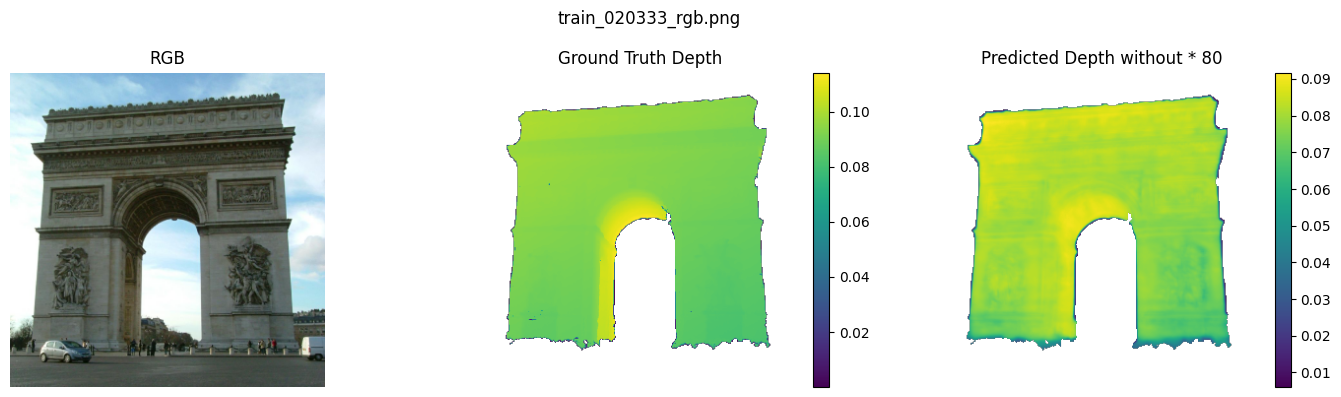

In [ ]:
model.eval()

batch = next(iter(val_loader))
images = batch["image"].to(DEVICE)
depths = batch["depth"].to(DEVICE)
masks = batch["mask"].to(DEVICE)
names = batch["name"]

with torch.no_grad():
    preds = model(images)

i = 0
img = images[i].cpu().permute(1, 2, 0).numpy()
gt = depths[i, 0].cpu().numpy()
pred = preds[i, 0].cpu().numpy()
mask = masks[i, 0].cpu().numpy()

# hide invalid gt pixels
gt_vis = gt.copy()
gt_vis[mask == 0] = np.nan
pred[mask == 0] = np.nan

plt.figure(figsize=(14, 4))

plt.subplot(1, 3, 1)
plt.imshow(img)
plt.title("RGB")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(gt_vis, cmap="viridis")
plt.title("Ground Truth Depth")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

# plt.subplot(1, 3, 3)
# plt.imshow(pred*80, cmap="viridis")
# plt.title("Predicted Depth")
# plt.axis("off")
# plt.colorbar(fraction=0.046, pad=0.04)

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="viridis")
plt.title("Predicted Depth without * 80")
plt.axis("off")
plt.colorbar(fraction=0.046, pad=0.04)

plt.suptitle(names[i])
plt.tight_layout()
plt.show()



In [ ]:
print(torch.cuda.get_device_name(0))
print(f"GPU cap:  {torch.cuda.get_device_capability(0)}")

print("Val batches:", len(val_loader))
print("Val samples:", len(val_dataset))

NVIDIA A100-SXM4-80GB
GPU cap:  (8, 0)
Val batches: 250
Val samples: 3000


In [ ]:
### submition pipeline

In [ ]:
TEST_ROOT  = Path("/cluster/courses/cil/monocular-depth-estimation/test")
PRED_DIR   = Path("./predictions")
PRED_DIR.mkdir(exist_ok=True)

IMG_SIZE = 320

model.eval()

test_rgb_files = sorted(TEST_ROOT.glob("test_*_rgb.png"))
print(f"Found {len(test_rgb_files)} test images")

with torch.no_grad():
    for img_path in test_rgb_files:
        rgb = np.array(Image.open(img_path).convert("RGB"), dtype=np.float32) / 255.0
        rgb_t = torch.from_numpy(rgb).permute(2, 0, 1).unsqueeze(0)
        rgb_t = F.interpolate(rgb_t, size=(IMG_SIZE, IMG_SIZE),
                              mode="bilinear", align_corners=False).to(DEVICE)

        pred = model(rgb_t)
        pred = pred.squeeze().cpu().numpy()
        pred = pred * 80.0

        idx = img_path.stem.split("_")[-2]
        out_path = PRED_DIR / f"test_{idx}.npy"
        np.save(out_path, pred.astype(np.float32))

print(f"Saved {len(test_rgb_files)} predictions to {PRED_DIR}")

Found 0 test images
Saved 0 predictions to predictions


In [ ]:
import base64, zlib, pandas as pd

def encode_depth(depth: np.ndarray) -> str:
    depth = np.asarray(depth, dtype=np.float16)
    compressed = zlib.compress(depth.tobytes(), level=9)
    return base64.b64encode(compressed).decode("utf-8")

pred_dir = Path("./predictions")   # same as PRED_DIR above
out_csv  = Path("./submission.csv")

rows = []
for pred_path in sorted(pred_dir.glob("test_*.npy")):
    depth = np.load(pred_path)
    idx   = pred_path.stem.split("_")[-1]
    rows.append({"id": f"test_{idx}_depth", "Depths": encode_depth(depth)})

df = pd.DataFrame(rows, columns=["id", "Depths"])
df.to_csv(out_csv, index=False)
print(f"Saved {len(df)} predictions → {out_csv}")

Saved 0 predictions → submission.csv


In [ ]:
from google.colab import drive
import os, shutil

# Mount Google Drive
drive.mount("/content/drive")

# Source file in current Colab runtime
src = "training_log.csv"

# Destination folder in Google Drive
export_dir = "/content/drive/MyDrive/colab_exports"
os.makedirs(export_dir, exist_ok=True)

# Destination file path
dst = os.path.join(export_dir, "training_log.csv")

# Check and copy
if not os.path.exists(src):
    raise FileNotFoundError(f"Could not find {src}. Check your current working directory.")

shutil.copy(src, dst)

print(f"Exported training_log.csv to: {dst}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Exported training_log.csv to: /content/drive/MyDrive/colab_exports/training_log.csv
